## Phase 1 — Environment Setup
### 1.1 Core Imports
Imports all required libraries: NumPy, Pandas, MNE (EEG), PyTorch, PyTorch Geometric, and utility packages.

In [1]:
# ==========================================
# PHASE 1.1 — CORE IMPORTS
# ==========================================

import os
import re
import json
import random
import numpy as np
import pandas as pd

# EEG Processing
import mne

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Graph Processing
import networkx as nx
from torch_geometric.data import Data

# Utilities
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

print("[DEBUG] Core libraries imported successfully")

[DEBUG] Core libraries imported successfully


### 1.2 Reproducibility
Sets fixed random seeds across Python, NumPy, and PyTorch to ensure reproducible results.

In [2]:
# ==========================================
# PHASE 1.2 — REPRODUCIBILITY
# ==========================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print("[DEBUG] Random seed set to 42")

[DEBUG] Random seed set to 42


### 1.3 Device Setup
Detects and sets the compute device — GPU (`cuda`) if available, otherwise `cpu`.

In [3]:
# ==========================================
# PHASE 1.3 — DEVICE SETUP
# ==========================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"[DEBUG] Using device: {DEVICE}")

[DEBUG] Using device: cuda


### 1.4 Global Config
Defines all pipeline hyperparameters in a single `CONFIG` dictionary. Derived values (`window_samples`, `step_size`) are computed automatically.

In [4]:
# ==========================================
# PHASE 1.4 — GLOBAL CONFIG
# ==========================================

CONFIG = {
    "sampling_rate": 256,
    "window_size_sec": 4,
    "overlap": 0.5,
    "sequence_length": 15,
    "correlation_threshold": 0.6,
    "batch_size": 16,
    "num_workers": 2
}

# Derived values
CONFIG["window_samples"] = int(CONFIG["sampling_rate"] * CONFIG["window_size_sec"])
CONFIG["step_size"] = int(CONFIG["window_samples"] * (1 - CONFIG["overlap"]))

print("[DEBUG] Config Loaded:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

[DEBUG] Config Loaded:
  sampling_rate: 256
  window_size_sec: 4
  overlap: 0.5
  sequence_length: 15
  correlation_threshold: 0.6
  batch_size: 16
  num_workers: 2
  window_samples: 1024
  step_size: 512


### 1.5 Debug Utilities
Defines `debug()` and `debug_shape()` helpers for consistent print-based logging throughout the notebook.

In [5]:
# ==========================================
# PHASE 1.5 — DEBUG UTIL
# ==========================================

def debug(msg):
    print(f"[DEBUG] {msg}")

def debug_shape(name, arr):
    try:
        print(f"[DEBUG] {name} shape: {arr.shape}")
    except:
        print(f"[DEBUG] {name}: {arr}")

### 1.6 Dataset Path
Sets the root path to the CHB-MIT EEG dataset and lists all patient directories.

In [6]:
# ==========================================
# PHASE 1.6 — DATASET PATH
# ==========================================

DATASET_PATH = r"C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0"  # CHANGE THIS

assert os.path.exists(DATASET_PATH), "Dataset path does not exist!"

patients = sorted([d for d in os.listdir(DATASET_PATH) if d.startswith("chb")])

debug(f"Total patients found: {len(patients)}")
debug(f"First 5 patients: {patients[:5]}")

[DEBUG] Total patients found: 24
[DEBUG] First 5 patients: ['chb01', 'chb02', 'chb03', 'chb04', 'chb05']


## Phase 2 — Data Loading
### 2.1 Get All EDF Files
Defines `get_all_edf_files()` — walks all patient directories and collects every `.edf` file path.

In [7]:
# ==========================================
# PHASE 2.1 — GET ALL EDF FILES
# ==========================================

def get_all_edf_files(dataset_path):
    edf_files = []

    for patient in patients:
        patient_path = os.path.join(dataset_path, patient)

        for file in os.listdir(patient_path):
            if file.endswith(".edf"):
                full_path = os.path.join(patient_path, file)
                edf_files.append(full_path)

    debug(f"Total EDF files found: {len(edf_files)}")
    return sorted(edf_files)

### Run — EDF File Discovery
Executes `get_all_edf_files()` and prints a sample of the discovered file paths.

In [8]:
edf_files = get_all_edf_files(DATASET_PATH)
print(edf_files[:3])

[DEBUG] Total EDF files found: 686
['C:\\Users\\vpokh\\Downloads\\archive\\chb-mit-scalp-eeg-database-1.0.0\\chb01\\chb01_01.edf', 'C:\\Users\\vpokh\\Downloads\\archive\\chb-mit-scalp-eeg-database-1.0.0\\chb01\\chb01_02.edf', 'C:\\Users\\vpokh\\Downloads\\archive\\chb-mit-scalp-eeg-database-1.0.0\\chb01\\chb01_03.edf']


### 2.2 Load EDF File
Defines `load_edf()` — loads a single `.edf` file using MNE with error handling. Returns `None` on failure.

In [9]:
# ==========================================
# PHASE 2.2 — LOAD EDF FILE
# ==========================================

def load_edf(file_path):
    debug(f"Loading file: {file_path}")

    try:
        raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)
        debug("EDF loaded successfully")

        return raw

    except Exception as e:
        debug(f"Error loading {file_path}: {e}")
        return None

### 2.3 Channel Standardization
Defines `clean_channels()` — maps every EDF to a fixed 18-channel montage. Missing channels are zero-filled to ensure consistent shape across all files.

In [10]:
# ==========================================
# FINAL CHANNEL STANDARDIZATION
# ==========================================

STANDARD_CHANNELS = [
    'FP1-F7','F7-T7','T7-P7','P7-O1',
    'FP1-F3','F3-C3','C3-P3','P3-O1',
    'FZ-CZ','CZ-PZ',
    'FP2-F4','F4-C4','C4-P4','P4-O2',
    'FP2-F8','F8-T8','T8-P8','P8-O2'
]

def clean_channels(raw):
    debug(f"Original channels: {len(raw.ch_names)}")

    data = raw.get_data()
    ch_names = raw.ch_names

    new_data = []
    final_channels = []

    for ch in STANDARD_CHANNELS:
        if ch in ch_names:
            idx = ch_names.index(ch)
            new_data.append(data[idx])
        else:
            # 🔴 MISSING CHANNEL → fill with zeros
            debug(f"[WARNING] Missing channel: {ch}")
            if ch == "T8-P8" and "F8-T8" in ch_names:
               idx = ch_names.index("F8-T8")
               new_data.append(data[idx].copy())

            elif ch == "P8-O2" and "T8-P8" in ch_names:
               idx = ch_names.index("T8-P8")
               new_data.append(data[idx].copy())

            else:
    # fallback
               new_data.append(np.mean(data, axis=0))

        final_channels.append(ch)

    new_data = np.array(new_data)

    debug(f"Final standardized channels: {len(final_channels)}")

    return new_data, final_channels, raw.info["sfreq"]

### 2.4 Raw to NumPy
Defines `raw_to_numpy()` — extracts the raw signal matrix `(channels × samples)` and sampling frequency from an MNE Raw object.

In [11]:
# ==========================================
# PHASE 2.4 — CONVERT TO NUMPY
# ==========================================

def raw_to_numpy(raw):
    data = raw.get_data()  # shape: (channels, samples)

    debug_shape("EEG Data", data)

    return data, raw.info["sfreq"], raw.ch_names

### 2.5 Full EDF Processor
Defines `process_edf()` — orchestrates load → standardize → return a dict with `file_path`, `data`, `sfreq`, and `channels`.

In [12]:
def process_edf(file_path):
    raw = load_edf(file_path)

    if raw is None:
        return None
    
    raw.pick_types(eeg=True)
    
    raw.filter(
    l_freq=0.5,
    h_freq=40,
    fir_design='firwin',
    verbose=False
    )

    raw.notch_filter(
    freqs=60,
    verbose=False
    )

    data, channels, sfreq = clean_channels(raw)

    debug_shape("EEG Data", data)
    debug(f"Sampling rate: {sfreq}")

    return {
        "file_path": file_path,
        "data": data,
        "sfreq": sfreq,
        "channels": channels
    }

## Phase 3 — Windowing & Labelling
### 3.1 Seizure Interval Converter
Defines `get_seizure_intervals()` — looks up seizure annotations and converts time in seconds to sample indices.

In [13]:
# ==========================================
# PHASE 3.1 — SEIZURE TIME → SAMPLE INDEX
# ==========================================

def get_seizure_intervals(file_name, seizure_map, sfreq):
    intervals = []

    if file_name not in seizure_map:
        debug(f"No seizure info for {file_name}")
        return intervals

    for seizure in seizure_map[file_name]:
        start_sample = int(seizure["start"] * sfreq)
        end_sample = int(seizure["end"] * sfreq)

        intervals.append((start_sample, end_sample))

    debug(f"{file_name} → {len(intervals)} seizures found")
    return intervals

### 3.2 Sliding Window
Defines `create_windows()` — slices the EEG signal into overlapping windows of shape `(num_windows, channels, window_samples)`.

In [14]:
# ==========================================
# PHASE 3.2 — SLIDING WINDOW
# ==========================================

def create_windows(data, window_size, step_size):
    """
    data: (channels, samples)
    returns: (num_windows, channels, window_size)
    """
    windows = []

    total_samples = data.shape[1]

    for start in range(0, total_samples - window_size, step_size):
        end = start + window_size
        segment = data[:, start:end]
        windows.append(segment)

    windows = np.array(windows)

    debug_shape("Windows", windows)
    return windows

### 3.3 Window Labeller
Defines `label_windows()` — assigns label `1` (seizure) to any window that overlaps a seizure interval, else `0`.

In [15]:
# ==========================================
# PHASE 3.3 — LABEL WINDOWS
# ==========================================

def label_windows(windows, seizure_intervals, step_size, window_size):
    labels = []

    for i in range(len(windows)):
        start = i * step_size
        end = start + window_size

        is_seizure = 0

        for (sz_start, sz_end) in seizure_intervals:
            # overlap condition
            if not (end < sz_start or start > sz_end):
                is_seizure = 1
                break

        labels.append(is_seizure)

    labels = np.array(labels)

    debug(f"Total seizure windows: {labels.sum()} / {len(labels)}")
    return labels

### 3.4 Near-Seizure Filter
Defines `filter_near_seizure()` — keeps all seizure windows plus any window within `margin` of a seizure boundary.

In [16]:
def filter_near_seizure(
    windows,
    labels,
    seizure_intervals,
    margin_sec=60
):

    margin = margin_sec * CONFIG["sampling_rate"]

    filtered_windows = []
    filtered_labels = []

    for i, label in enumerate(labels):

        sample_pos = i * CONFIG["step_size"]

        keep = False

        for start, end in seizure_intervals:

            if (start - margin) <= sample_pos <= (end + margin):
                keep = True
                break

        if label == 1 or keep:
            filtered_windows.append(windows[i])
            filtered_labels.append(label)

    return np.array(filtered_windows), np.array(filtered_labels)

### 3.5 Full File Segmenter
Defines `segment_full_file()` — main segmentation function. Applies near-seizure filtering for seizure files and caps baseline windows for non-seizure files.

In [17]:
def segment_full_file(sample, seizure_map):
    data = sample["data"]
    sfreq = sample["sfreq"]
    file_name = os.path.basename(sample["file_path"])

    debug(f"[FULL] Segmenting file: {file_name}")

    # 🔹 Get seizure intervals
    seizure_intervals = get_seizure_intervals(file_name, seizure_map, sfreq)

    # 🔹 Create windows
    windows = create_windows(
        data,
        CONFIG["window_samples"],
        CONFIG["step_size"]
    )

    # 🔹 Label windows
    labels = label_windows(
        windows,
        seizure_intervals,
        CONFIG["step_size"],
        CONFIG["window_samples"]
    )

    # =========================================================
    #  CASE 1: FILE HAS SEIZURES
    # =========================================================
    if len(seizure_intervals) > 0:

        # Step 1: filter near seizure region
        filtered_windows, filtered_labels = filter_near_seizure(
            windows,
            labels,
            seizure_intervals,
            margin_sec=60
        )

        # Step 2: FORCE ADD NON-SEIZURE WINDOWS
        original_non_seizure_idx = np.where(labels == 0)[0]

        if len(original_non_seizure_idx) > 0:
            extra_count = min(300, len(original_non_seizure_idx))

            extra_idx = np.random.choice(
                original_non_seizure_idx,
                extra_count,
                replace=False
            )

            #  Combine filtered + extra baseline
            extra_windows = windows[extra_idx]
            extra_labels  = labels[extra_idx]
            windows = np.concatenate([filtered_windows, extra_windows], axis=0)
            labels  = np.concatenate([filtered_labels,  extra_labels],  axis=0)

        else:
            windows = filtered_windows
            labels = filtered_labels

    # =========================================================
    #  CASE 2: NO SEIZURE FILE
    # =========================================================
    else:
        debug("No seizures → keeping limited baseline windows")

        max_keep = 200

        if len(windows) > max_keep:
            idx = np.random.choice(len(windows), max_keep, replace=False)
            windows = windows[idx]
            labels = labels[idx]

    # 🔹 Final safety
    labels = labels.astype(int)

    debug(f"[FULL] Windows: {windows.shape}")
    debug(f"[FULL] Labels: {np.bincount(labels)}")

    return windows, labels

### 3.6 Summary File Parser
Defines `parse_summary_file()` — parses CHB-MIT `*-summary.txt` files to extract per-file seizure start/end times.

In [18]:
# ==========================================
# FINAL ROBUST SUMMARY PARSER
# ==========================================

def parse_summary_file(filepath):
    debug(f"Parsing summary: {filepath}")

    with open(filepath, 'r') as f:
        lines = f.readlines()

    file_data = {}
    current_file = None

    for line in lines:
        line = line.strip()

        # ---- FILE DETECTION ----
        if line.startswith("File Name:"):
            current_file = line.split(":")[1].strip()
            file_data[current_file] = []

        # ---- STRICT START TIME ----
        elif re.match(r"Seizure \d+ Start Time:", line):
            numbers = re.findall(r'\d+', line)

            if len(numbers) < 2:
                debug(f"[WARNING] Bad start line: {line}")
                continue

            start = int(numbers[1])  # second number = time

            if current_file:
                file_data[current_file].append({"start": start})

        # ---- STRICT END TIME ----
        elif re.match(r"Seizure \d+ End Time:", line):
            numbers = re.findall(r'\d+', line)

            if len(numbers) < 2:
                debug(f"[WARNING] Bad end line: {line}")
                continue

            end = int(numbers[1])

            if current_file and len(file_data[current_file]) > 0:
                file_data[current_file][-1]["end"] = end

    debug(f"Parsed {len(file_data)} files")
    return file_data

### 3.7 Seizure Map Builder
Defines and runs `build_seizure_map()` — iterates over all patient summaries and builds a flat dict mapping EDF filenames to their seizure intervals.

In [19]:
def build_seizure_map(dataset_path):
    seizure_map = {}

    for patient in patients:
        summary_path = os.path.join(dataset_path, patient, f"{patient}-summary.txt")

        if not os.path.exists(summary_path):
            debug(f"Missing summary for {patient}")
            continue

        parsed = parse_summary_file(summary_path)

        for file_name, seizures in parsed.items():
            seizure_map[file_name] = seizures

    debug(f"Total files mapped: {len(seizure_map)}")
    return seizure_map

seizure_map = build_seizure_map(DATASET_PATH)

debug("Seizure map created successfully")

[DEBUG] Parsing summary: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb01\chb01-summary.txt
[DEBUG] Parsed 42 files
[DEBUG] Parsing summary: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb02\chb02-summary.txt
[DEBUG] Parsed 13 files
[DEBUG] Parsing summary: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb03\chb03-summary.txt
[DEBUG] Parsed 38 files
[DEBUG] Parsing summary: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb04\chb04-summary.txt
[DEBUG] Parsed 42 files
[DEBUG] Parsing summary: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb05\chb05-summary.txt
[DEBUG] Parsed 39 files
[DEBUG] Parsing summary: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb06\chb06-summary.txt
[DEBUG] Parsed 18 files
[DEBUG] Parsing summary: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb07\chb07-summary.txt
[DEBUG] Parsed 19 files
[DEBUG] Parsing summary: C:

### 3.8 Non-Ictal Window Sampler
Defines `select_non_ictal_windows()` — samples a controlled number of non-ictal windows using a pre-ictal mask and a seizure/non-seizure ratio.

In [20]:
# ==========================================
# FIX — HANDLE NO-SEIZURE FILES
# ==========================================

def select_non_ictal_windows(labels, preictal_mask, ratio=2, max_baseline=200):
    ictal_idx = np.where(labels == 1)[0]
    non_ictal_idx = np.where((labels == 0) & (preictal_mask == 0))[0]

    debug(f"Raw non-ictal: {len(non_ictal_idx)}")

    # 🔴 CASE 1: NO SEIZURES
    if len(ictal_idx) == 0:
        debug("No seizures in file → selecting baseline windows")

        if len(non_ictal_idx) > max_baseline:
            selected_idx = np.random.choice(non_ictal_idx, max_baseline, replace=False)
        else:
            selected_idx = non_ictal_idx

        return selected_idx

    # 🟢 CASE 2: HAS SEIZURES
    max_non_ictal = len(ictal_idx) * ratio

    if len(non_ictal_idx) > max_non_ictal:
        selected_non_ictal = np.random.choice(non_ictal_idx, max_non_ictal, replace=False)
    else:
        selected_non_ictal = non_ictal_idx

    final_idx = np.concatenate([ictal_idx, selected_non_ictal])
    np.random.shuffle(final_idx)

    debug(f"Final dataset size: {len(final_idx)}")

    return final_idx

### Run — Find Seizure Files
Filters the seizure map to list all files that contain at least one seizure.

In [21]:
# ==========================================
# FIND A FILE WITH SEIZURES
# ==========================================

seizure_files = [f for f, v in seizure_map.items() if len(v) > 0]

print("Total seizure files:", len(seizure_files))
print("Sample seizure file:", seizure_files[0])

Total seizure files: 105
Sample seizure file: chb04_28.edf


### Utility — Get Full File Path
Defines `get_full_path()` — resolves a bare filename to its absolute path. Also picks the first seizure file for testing.

In [22]:
def get_full_path(file_name, dataset_path):
    patient = file_name.split("_")[0]
    return os.path.join(dataset_path, patient, file_name)

file_name = seizure_files[0]  # pick first seizure file
file_path = get_full_path(file_name, DATASET_PATH)

print(file_path)

C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb04\chb04_28.edf


### Run — Segmentation Smoke Test
Loads one seizure file end-to-end and prints window shape and label distribution as a sanity check.

In [23]:
sample2 = process_edf(file_path)

windows, labels = segment_full_file(sample2, seizure_map)

print("Shape:", windows.shape)
print("Label distribution:", np.bincount(labels))

[DEBUG] Loading file: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb04\chb04_28.edf
[DEBUG] EDF loaded successfully
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
[DEBUG] Original channels: 24
[DEBUG] [WARNING] Missing channel: T8-P8
[DEBUG] Final standardized channels: 18
[DEBUG] EEG Data shape: (18, 3692288)
[DEBUG] Sampling rate: 256.0
[DEBUG] [FULL] Segmenting file: chb04_28.edf
[DEBUG] chb04_28.edf → 2 seizures found
[DEBUG] Windows shape: (7210, 18, 1024)
[DEBUG] Total seizure windows: 114 / 7210
[DEBUG] [FULL] Windows: (530, 18, 1024)
[DEBUG] [FULL] Labels: [416 114]
Shape: (530, 18, 1024)
Label distribution: [416 114]


## Phase 4 — Graph Construction
### 4.1 Correlation Matrix
Defines `compute_correlation_matrix()` — computes the absolute Pearson correlation matrix `(channels × channels)` for a single window.

In [24]:
# ==========================================
# PHASE 4.1 — BUILD CORRELATION MATRIX
# ==========================================

def compute_correlation_matrix(window):
    """
    window: (channels, samples)
    returns: (channels, channels)
    """
    corr = np.corrcoef(window)
    corr = np.abs(corr)
    np.fill_diagonal(corr, 0)

    # replace NaNs
    corr = np.nan_to_num(corr)

    return corr

### 4.2 Adjacency Thresholding
Defines `threshold_adj_matrix()` — zeros out correlations below `correlation_threshold` to produce a sparse adjacency matrix.

In [25]:
# ==========================================
# PHASE 4.2 — THRESHOLD GRAPH
# ==========================================

def threshold_adj_matrix(adj, threshold=0.5):
    adj = np.where(np.abs(adj) >= threshold, adj, 0)
    return adj

### 4.3 Node Feature Extractor
Defines `extract_node_features()` — computes 6 time-domain features per channel: mean, std, min, max, energy, line length.

In [26]:
# ==========================================
# PHASE 4.3 — ENHANCED NODE FEATURES
# ==========================================

from scipy.signal import welch
from scipy.stats import entropy as scipy_entropy

# Seizure-relevant frequency bands
FREQ_BANDS = {
    "delta": (1,   4),
    "theta": (4,   8),
    "alpha": (8,  13),
    "beta":  (13, 30),
    "gamma": (30, 40),   # capped at filter cutoff
}

def compute_band_powers(signal, fs=256):
    """
    Compute log band power in each seizure-relevant frequency band.
    Returns 5 values: delta, theta, alpha, beta, gamma.
    Log-transform stabilises variance across patients.
    """
    freqs, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    freq_res = freqs[1] - freqs[0]

    band_powers = []
    for band, (lo, hi) in FREQ_BANDS.items():
        idx = np.logical_and(freqs >= lo, freqs <= hi)
        bp = np.trapz(psd[idx], freqs[idx])
        band_powers.append(np.log1p(bp))   # log1p avoids log(0)

    return np.array(band_powers)   # shape: (5,)


def compute_spectral_entropy(signal, fs=256):
    """
    Spectral entropy: measures how spread-out the PSD is.
    LOW during seizure (energy concentrates in narrow bands).
    HIGH during normal EEG (energy spread across all bands).
    Extremely discriminative for seizure detection.
    """
    _, psd = welch(signal, fs=fs, nperseg=min(256, len(signal)))
    psd_norm = psd / (psd.sum() + 1e-10)
    return scipy_entropy(psd_norm + 1e-10)   # scalar


def compute_hjorth_parameters(signal):
    """
    Hjorth mobility and complexity.
    - Mobility: mean frequency proxy. INCREASES during seizure.
    - Complexity: signal complexity. CHANGES characteristically during seizure.
    Both are amplitude-independent (computed on differences), 
    so they remain valid after per-channel normalisation.
    """
    d1 = np.diff(signal)
    d2 = np.diff(d1)

    var0 = np.var(signal) + 1e-10
    var1 = np.var(d1)     + 1e-10
    var2 = np.var(d2)     + 1e-10

    mobility   = np.sqrt(var1 / var0)
    complexity = np.sqrt(var2 / var1) / mobility

    return mobility, complexity   # 2 scalars


def extract_node_features(window):
    """
    window: (channels, samples) — already normalised to zero-mean unit-variance
    Returns: (channels, 10) feature matrix

    Features per channel:
      0    — std (amplitude after normalisation — still informative as relative scale)
      1    — line length (signal complexity proxy, seizure-sensitive)
      2    — energy (RMS energy, seizure shows elevated energy)
      3-7  — log band powers: delta, theta, alpha, beta, gamma
      8    — spectral entropy (low during seizure)
      9    — Hjorth mobility
      10   — Hjorth complexity
    Total: 11 features

    REMOVED: mean (≈0 after normalisation), min, max (redundant with std)
    """
    n_ch = window.shape[0]
    feats = []

    for ch_idx in range(n_ch):
        sig = window[ch_idx]

        std    = np.std(sig)
        ll     = np.abs(np.diff(sig)).mean()
        energy = np.sqrt(np.mean(sig ** 2))   # RMS

        band_pows = compute_band_powers(sig)        # (5,)
        sp_ent    = compute_spectral_entropy(sig)   # scalar
        mob, cmp  = compute_hjorth_parameters(sig)  # 2 scalars

        ch_feat = np.concatenate([
            [std, ll, energy],
            band_pows,
            [sp_ent, mob, cmp]
        ])   # shape: (11,)

        feats.append(ch_feat)

    return np.array(feats)   # shape: (channels, 11)

### 4.4 Band Power Feature
Defines `bandpower()` — adds a 7th node feature using average PSD power via Welch's method.

### 4.5 Graph Object Builder
Defines `create_graph()` — assembles a PyG `Data` object per window with node features `(18×7)`, edge index, edge weights, and label.

In [27]:
# ==========================================
# PHASE 4.5 — GRAPH OBJECT (UPDATED)
# ==========================================

def create_graph(window, label):
    # Per-channel normalisation (amplitude-independent features)
    std_per_ch = window.std(axis=1, keepdims=True) + 1e-8
    window_norm = (window - window.mean(axis=1, keepdims=True)) / std_per_ch

    # --- NODE FEATURES ---
    features = extract_node_features(window_norm)   # (18, 11)
    x = torch.tensor(features, dtype=torch.float)

    # --- EDGE CONSTRUCTION: top-k instead of hard threshold ---
    # Hard threshold at 0.6 can produce zero-edge graphs for non-seizure
    # windows, making GAT layers degenerate. Top-k guarantees connectivity.
    corr = compute_correlation_matrix(window_norm)  # (18, 18)

    # Keep top-6 neighbours per node (k=6 out of 17 possible)
    K = 6
    edge_rows, edge_cols, edge_vals = [], [], []

    for i in range(corr.shape[0]):
        row = corr[i].copy()
        row[i] = 0   # no self-loops
        top_k_idx = np.argsort(row)[-K:]
        for j in top_k_idx:
            if row[j] > 0:
                edge_rows.append(i)
                edge_cols.append(j)
                edge_vals.append(row[j])

    if len(edge_rows) == 0:
        # Fallback: connect each node to its nearest neighbour
        for i in range(corr.shape[0]):
            row = corr[i].copy()
            row[i] = 0
            j = np.argmax(row)
            edge_rows.append(i)
            edge_cols.append(j)
            edge_vals.append(row[j])

    edge_index = torch.tensor([edge_rows, edge_cols], dtype=torch.long)
    edge_attr  = torch.tensor(edge_vals, dtype=torch.float)

    y = torch.tensor([label], dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
    return data

### Run — Single Graph Test
Builds one graph from the first window and prints its node feature shape and edge count.

In [28]:
graph = create_graph(windows[0], labels[0])

print(graph)
print("Node features:", graph.x.shape)
print("Edges:", graph.edge_index.shape)

Data(x=[18, 11], edge_index=[2, 108], edge_attr=[108], y=[1])
Node features: torch.Size([18, 11])
Edges: torch.Size([2, 108])


## Phase 5 — Sequence Construction
### 5.1 Windows to Graphs
Defines `windows_to_graphs()` — converts an array of EEG windows into a list of PyG graph objects.

In [29]:
# ==========================================
# PHASE 5.1 — WINDOWS → GRAPHS
# ==========================================

def windows_to_graphs(windows, labels):
    graphs = []

    for i in range(len(windows)):
        g = create_graph(windows[i], labels[i])
        graphs.append(g)

    debug(f"Converted {len(graphs)} windows → graphs")
    return graphs

### 5.2 Graph Sequences
Defines `create_graph_sequences()` — groups consecutive graphs into temporal sequences of length `seq_len`, labelled by the last graph.

In [30]:
# ==========================================
# PHASE 5.2 — GRAPH SEQUENCES
# ==========================================

def create_graph_sequences(graphs, seq_len):
    sequences = []
    labels = []

    for i in range(len(graphs) - seq_len):
        seq = graphs[i:i+seq_len]

        # label = label of LAST graph (important for temporal learning)
        label = graphs[i+seq_len-1].y.item()

        sequences.append(seq)
        labels.append(label)

    debug(f"Created {len(sequences)} sequences")
    return sequences, labels

### 5.3 Patient-Level Balancer
Defines `balance_patient_data()` — balances seizure vs non-seizure sequences per patient at a configurable ratio.

In [31]:
def balance_patient_data(sequences, labels, ratio=2):
    labels = np.array(labels)

    seizure_idx = np.where(labels == 1)[0]
    non_idx = np.where(labels == 0)[0]

    if len(seizure_idx) == 0:
        return [], []

    max_non = min(len(non_idx), ratio * len(seizure_idx))

    selected_non = np.random.choice(non_idx, max_non, replace=False)

    final_idx = np.concatenate([seizure_idx, selected_non])
    np.random.shuffle(final_idx)

    sequences = [sequences[i] for i in final_idx]
    labels = labels[final_idx]

    return sequences, labels

### 5.4 Full Dataset Builder
Defines `build_full_dataset()` — main data pipeline loop: loads each EDF, segments, converts to graphs and sequences, then applies per-patient balancing.

In [32]:
def build_full_dataset(edf_files, seizure_map):
    all_sequences = []
    all_labels = []
    all_patient_ids = []

    #  NEW: patient-wise storage
    patient_data = {}

    for file_path in tqdm(edf_files):

        file_name = os.path.basename(file_path)

        if file_name not in seizure_map:
            continue

        try:
            sample = process_edf(file_path)

            windows, labels = segment_full_file(sample, seizure_map)

            if len(windows) == 0:
                continue

            graphs = windows_to_graphs(windows, labels)

            sequences, seq_labels = create_graph_sequences(
                graphs,
                CONFIG["sequence_length"]
            )

            patient_id = file_name.split("_")[0]

            #  STORE PER PATIENT (NOT GLOBAL)
            if patient_id not in patient_data:
                patient_data[patient_id] = {
                    "seq": [],
                    "lbl": []
                }

            patient_data[patient_id]["seq"].extend(sequences)
            patient_data[patient_id]["lbl"].extend(seq_labels)

        except Exception as e:
            debug(f"Error in {file_path}: {e}")

    # ==========================================
    #  APPLY BALANCING PER PATIENT
    # ==========================================

    MAX_PER_PATIENT = 400   # hard cap — no patient dominates

    for patient_id, data in patient_data.items():
        seqs = data["seq"]
        lbls = np.array(data["lbl"])

        seizure_idx = np.where(lbls == 1)[0]
        non_idx     = np.where(lbls == 0)[0]

        if len(seizure_idx) == 0:
            continue

    # Cap seizure sequences first
        max_seizure = min(len(seizure_idx), MAX_PER_PATIENT // 2)
        selected_sz  = np.random.choice(seizure_idx, max_seizure, replace=False)

    # Non-seizure = 2× seizure, also capped
        max_non = min(len(non_idx), max_seizure * 2)
        selected_non = np.random.choice(non_idx, max_non, replace=False)

        final_idx = np.concatenate([selected_sz, selected_non])
        np.random.shuffle(final_idx)

        balanced_seqs = [seqs[i] for i in final_idx]
        balanced_lbls = lbls[final_idx]

        all_sequences.extend(balanced_seqs)
        all_labels.extend(balanced_lbls)
        all_patient_ids.extend([patient_id] * len(balanced_seqs))
    debug(f"TOTAL sequences AFTER BALANCE: {len(all_sequences)}")

    return all_sequences, all_labels, all_patient_ids

### Utility — Get Full File Path (Helper)
Defines `get_full_path()` helper used by the dataset builder to resolve filenames to absolute paths.

In [33]:
def get_full_path(file_name, dataset_path):
    patient = file_name.split("_")[0]
    return os.path.join(dataset_path, patient, file_name)

### Build File Path List
Separates seizure and non-seizure files, balances their counts, and resolves all filenames to absolute paths.

In [34]:
# ==========================================
# FIX — BUILD CORRECT FILE PATHS
# ==========================================

seizure_files = [f for f, v in seizure_map.items() if len(v) > 0]
non_seizure_files = [f for f, v in seizure_map.items() if len(v) == 0]

# limit non-seizure
non_seizure_files = non_seizure_files[:len(seizure_files)]

final_files = seizure_files + non_seizure_files

#  CRITICAL FIX HERE
file_paths = [get_full_path(f, DATASET_PATH) for f in final_files]

### Run — Build Full Dataset
Executes `build_full_dataset()` to process all files and produce `all_sequences`, `all_labels`, and `all_patient_ids`.

In [35]:
all_sequences, all_labels, all_patient_ids = build_full_dataset(
    file_paths,   # ✅ NOT final_files
    seizure_map
)

  0%|          | 0/210 [00:00<?, ?it/s]

[DEBUG] Loading file: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb04\chb04_28.edf
[DEBUG] EDF loaded successfully
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
[DEBUG] Original channels: 24
[DEBUG] [WARNING] Missing channel: T8-P8
[DEBUG] Final standardized channels: 18
[DEBUG] EEG Data shape: (18, 3692288)
[DEBUG] Sampling rate: 256.0
[DEBUG] [FULL] Segmenting file: chb04_28.edf
[DEBUG] chb04_28.edf → 2 seizures found
[DEBUG] Windows shape: (7210, 18, 1024)
[DEBUG] Total seizure windows: 114 / 7210
[DEBUG] [FULL] Windows: (530, 18, 1024)
[DEBUG] [FULL] Labels: [416 114]


  0%|          | 1/210 [00:15<52:51, 15.17s/it]

[DEBUG] Converted 530 windows → graphs
[DEBUG] Created 515 sequences
[DEBUG] Loading file: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb06\chb06_01.edf
[DEBUG] EDF loaded successfully
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
[DEBUG] Original channels: 23
[DEBUG] [WARNING] Missing channel: T8-P8
[DEBUG] Final standardized channels: 18
[DEBUG] EEG Data shape: (18, 3693312)
[DEBUG] Sampling rate: 256.0
[DEBUG] [FULL] Segmenting file: chb06_01.edf
[DEBUG] chb06_01.edf → 3 seizures found
[DEBUG] Windows shape: (7212, 18, 1024)
[DEBUG] Total seizure windows: 30 / 7212
[DEBUG] [FULL] Windows: (504, 18, 1024)
[DEBUG] [FULL] Labels: [474  30]


  1%|          | 2/210 [00:27<46:58, 13.55s/it]

...

[DEBUG] Converted 200 windows → graphs
[DEBUG] Created 185 sequences
[DEBUG] Loading file: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb04\chb04_25.edf
[DEBUG] EDF loaded successfully
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
[DEBUG] Original channels: 24
[DEBUG] [WARNING] Missing channel: T8-P8
[DEBUG] Final standardized channels: 18
[DEBUG] EEG Data shape: (18, 3686400)
[DEBUG] Sampling rate: 256.0
[DEBUG] [FULL] Segmenting file: chb04_25.edf
[DEBUG] chb04_25.edf → 0 seizures found
[DEBUG] Windows shape: (7198, 18, 1024)
[DEBUG] Total seizure windows: 0 / 7198
[DEBUG] No seizures → keeping limited baseline windows
[DEBUG] [FULL] Windows: (200, 18, 1024)
[DEBUG] [FULL] Labels: [200]


100%|█████████▉| 209/210 [22:49<00:08,  8.69s/it]

[DEBUG] Converted 200 windows → graphs
[DEBUG] Created 185 sequences
[DEBUG] Loading file: C:\Users\vpokh\Downloads\archive\chb-mit-scalp-eeg-database-1.0.0\chb04\chb04_26.edf
[DEBUG] EDF loaded successfully
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
[DEBUG] Original channels: 24
[DEBUG] [WARNING] Missing channel: T8-P8
[DEBUG] Final standardized channels: 18
[DEBUG] EEG Data shape: (18, 3686400)
[DEBUG] Sampling rate: 256.0
[DEBUG] [FULL] Segmenting file: chb04_26.edf
[DEBUG] chb04_26.edf → 0 seizures found
[DEBUG] Windows shape: (7198, 18, 1024)
[DEBUG] Total seizure windows: 0 / 7198
[DEBUG] No seizures → keeping limited baseline windows
[DEBUG] [FULL] Windows: (200, 18, 1024)
[DEBUG] [FULL] Labels: [200]


100%|██████████| 210/210 [22:58<00:00,  6.56s/it]

[DEBUG] Converted 200 windows → graphs
[DEBUG] Created 185 sequences
[DEBUG] TOTAL sequences AFTER BALANCE: 8352


### Run — Dataset Size Check
Prints total sequence count and overall class distribution.

In [36]:
print("Total:", len(all_labels))
print("Distribution:", np.bincount(all_labels))


Total: 8352
Distribution: [5568 2784]


### Run — Per-Patient Sample Counts
Breaks down the number of sequences per patient.

In [37]:
# ==========================================
# CHECK PATIENT DISTRIBUTION
# ==========================================

from collections import Counter

patient_counts = Counter(all_patient_ids)

print("Total patients:", len(patient_counts))
print("\nSamples per patient:\n")

for patient, count in sorted(patient_counts.items()):
    print(f"{patient}: {count}")

Total patients: 18

Samples per patient:

chb04: 342
chb06: 300
chb07: 510
chb08: 600
chb09: 441
chb10: 600
chb11: 600
chb12: 600
chb13: 600
chb14: 309
chb15: 600
chb16: 207
chb18: 516
chb19: 375
chb20: 501
chb21: 327
chb22: 324
chb23: 600


### Run — Class Distribution Per Patient
Prints seizure vs non-seizure sequence counts for each patient.

## Phase 6 — Persistence
### Save Dataset
Serializes the full dataset to a `.pkl` file so the pipeline does not need to be re-run from scratch.

In [39]:
import pickle

# ==========================================
# SAVE DATASET
# ==========================================

save_path = "gnn_lstm_eeg_dataset29.pkl"

with open(save_path, "wb") as f:
    pickle.dump({
        "sequences": all_sequences,
        "labels": all_labels,
        "patient_ids": all_patient_ids
    }, f)

print(f"[DEBUG] Dataset saved at: {save_path}")

[DEBUG] Dataset saved at: gnn_lstm_eeg_dataset29.pkl


### Load Dataset
Loads the previously saved `.pkl` dataset back into memory. Run this instead of the full pipeline when the file already exists.

In [35]:
import pickle
with open(r"C:\Users\vpokh\Downloads\gnn_lstm_eeg_dataset29.pkl", "rb") as f:
    data = pickle.load(f)

all_sequences = data["sequences"]
all_labels = data["labels"]
all_patient_ids = data["patient_ids"]

### Run — Class Distribution Per Patient

Iterates over all sequences and accumulates per-patient counts of seizure (`label=1`) and non-seizure (`label=0`) sequences. Prints a breakdown table so data balance can be verified before splitting into train / test sets.

In [36]:
# ==========================================
# CLASS DISTRIBUTION PER PATIENT
# ==========================================

patient_class_dist = {}

for seq, lbl, pid in zip(all_sequences, all_labels, all_patient_ids):
    if pid not in patient_class_dist:
        patient_class_dist[pid] = [0, 0]
    
    patient_class_dist[pid][lbl] += 1

print("\nClass distribution per patient:\n")

for pid, (non_sz, sz) in sorted(patient_class_dist.items()):
    print(f"{pid}: Non-seizure={non_sz}, Seizure={sz}")


Class distribution per patient:

chb04: Non-seizure=228, Seizure=114
chb06: Non-seizure=200, Seizure=100
chb07: Non-seizure=340, Seizure=170
chb08: Non-seizure=400, Seizure=200
chb09: Non-seizure=294, Seizure=147
chb10: Non-seizure=400, Seizure=200
chb11: Non-seizure=400, Seizure=200
chb12: Non-seizure=400, Seizure=200
chb13: Non-seizure=400, Seizure=200
chb14: Non-seizure=206, Seizure=103
chb15: Non-seizure=400, Seizure=200
chb16: Non-seizure=138, Seizure=69
chb18: Non-seizure=344, Seizure=172
chb19: Non-seizure=250, Seizure=125
chb20: Non-seizure=334, Seizure=167
chb21: Non-seizure=218, Seizure=109
chb22: Non-seizure=216, Seizure=108
chb23: Non-seizure=400, Seizure=200


### Filter Valid Patients
Keeps only patients that have at least one seizure sequence after balancing.

In [38]:
# ==========================================
# FILTER VALID PATIENTS
# ==========================================

valid_patients = []

for pid, (non_sz, sz) in patient_class_dist.items():
    if sz > 0:
        valid_patients.append(pid)

print("Valid patients:", valid_patients)

Valid patients: ['chb04', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23']


### Filter Dataset
Removes all sequences belonging to patients that were excluded in the previous step.

In [39]:
# ==========================================
# FILTER DATASET
# ==========================================

filtered_sequences = []
filtered_labels = []
filtered_patient_ids = []

for seq, lbl, pid in zip(all_sequences, all_labels, all_patient_ids):
    if pid in valid_patients:
        filtered_sequences.append(seq)
        filtered_labels.append(lbl)
        filtered_patient_ids.append(pid)

print("Filtered size:", len(filtered_labels))
print("New distribution:", np.bincount(filtered_labels))

Filtered size: 8352
New distribution: [5568 2784]


## Phase 7 — Train / Test Split
### Patient-Wise Split
Randomly splits patients 80/20 into train and test groups to prevent data leakage across subjects.

### Build Train / Test Sets
Partitions sequences and labels into train and test lists based on the patient-wise split.

In [40]:
# ==========================================
# PATIENT-WISE STRATIFIED SPLIT
# ==========================================

import random
import numpy as np
from collections import Counter

random.seed(42)

# ------------------------------------------
# STEP 1: Count seizure sequences per patient
# ------------------------------------------

patient_sz_counts = {}
patient_total_counts = {}

for pid, lbl in zip(filtered_patient_ids, filtered_labels):
    if pid not in patient_sz_counts:
        patient_sz_counts[pid]    = 0
        patient_total_counts[pid] = 0
    patient_sz_counts[pid]    += int(lbl)
    patient_total_counts[pid] += 1

# ------------------------------------------
# STEP 2: Stratified split by seizure count
# Sort patients so high/low seizure patients
# are distributed across all three splits
# ------------------------------------------

sorted_patients = sorted(
    valid_patients,
    key=lambda p: patient_sz_counts.get(p, 0)
)

# Assign: every 5th → test, every 4th → val, rest → train
# This interleaves patients by seizure count so each split
# gets a mix of easy and hard patients
train_patients_final = []
val_patients_final   = []
test_patients        = []

for i, pid in enumerate(sorted_patients):
    if i % 5 == 0:
        test_patients.append(pid)
    elif i % 5 == 1:
        val_patients_final.append(pid)
    else:
        train_patients_final.append(pid)

print("Train patients:", sorted(train_patients_final))
print("Val patients:  ", sorted(val_patients_final))
print("Test patients: ", sorted(test_patients))

# ------------------------------------------
# STEP 3: Build datasets
# ------------------------------------------

train_seq_new, val_seq, test_seq         = [], [], []
train_lbl_new, val_lbl, test_lbl         = [], [], []
train_pids,    val_pids,    test_pids    = [], [], []

for seq, lbl, pid in zip(filtered_sequences, filtered_labels, filtered_patient_ids):
    if pid in train_patients_final:
        train_seq_new.append(seq)
        train_lbl_new.append(lbl)
        train_pids.append(pid)
    elif pid in val_patients_final:
        val_seq.append(seq)
        val_lbl.append(lbl)
        val_pids.append(pid)
    elif pid in test_patients:
        test_seq.append(seq)
        test_lbl.append(lbl)
        test_pids.append(pid)

train_lbl_new = np.array(train_lbl_new)
val_lbl       = np.array(val_lbl)
test_lbl      = np.array(test_lbl)

# ------------------------------------------
# STEP 4: Verify no patient dominates
# ------------------------------------------

def check_split_balance(name, seqs, pids, lbls):
    print(f"\n{name} — {len(seqs)} sequences total")
    print(f"  Distribution: {np.bincount(lbls)}")
    print(f"  Seizure rate: {lbls.mean():.2%}")
    pid_counts = Counter(pids)
    for pid, cnt in sorted(pid_counts.items()):
        frac = cnt / len(seqs)
        flag = "⚠️ DOMINATES" if frac > 0.30 else "✓"
        print(f"  {flag}  {pid}: {cnt} ({frac:.0%})")

check_split_balance("TRAIN", train_seq_new, train_pids, train_lbl_new)
check_split_balance("VAL",   val_seq,       val_pids,   val_lbl)
check_split_balance("TEST",  test_seq,      test_pids,  test_lbl)

print("\nFirst 30 train labels:")
print(train_lbl_new[:30].tolist())

Train patients: ['chb07', 'chb09', 'chb10', 'chb11', 'chb12', 'chb14', 'chb20', 'chb21', 'chb22', 'chb23']
Val patients:   ['chb06', 'chb08', 'chb15', 'chb19']
Test patients:  ['chb04', 'chb13', 'chb16', 'chb18']

TRAIN — 4812 sequences total
  Distribution: [3208 1604]
  Seizure rate: 33.33%
  ✓  chb07: 510 (11%)
  ✓  chb09: 441 (9%)
  ✓  chb10: 600 (12%)
  ✓  chb11: 600 (12%)
  ✓  chb12: 600 (12%)
  ✓  chb14: 309 (6%)
  ✓  chb20: 501 (10%)
  ✓  chb21: 327 (7%)
  ✓  chb22: 324 (7%)
  ✓  chb23: 600 (12%)

VAL — 1875 sequences total
  Distribution: [1250  625]
  Seizure rate: 33.33%
  ✓  chb06: 300 (16%)
  ⚠️ DOMINATES  chb08: 600 (32%)
  ⚠️ DOMINATES  chb15: 600 (32%)
  ✓  chb19: 375 (20%)

TEST — 1665 sequences total
  Distribution: [1110  555]
  Seizure rate: 33.33%
  ✓  chb04: 342 (21%)
  ⚠️ DOMINATES  chb13: 600 (36%)
  ✓  chb16: 207 (12%)
  ⚠️ DOMINATES  chb18: 516 (31%)

First 30 train labels:
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,

## Phase 8 — Model
### New Imports for GAT Model
Imports `GATConv`, `WeightedRandomSampler`, and scikit-learn evaluation metrics.

In [41]:
# ==========================================
# NEW IMPORTS FOR GAT MODEL
# ==========================================

from torch_geometric.nn import GATConv
from torch.utils.data import WeightedRandomSampler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, matthews_corrcoef,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

debug("New imports loaded")

[DEBUG] New imports loaded


### GAT Encoder
Defines `GATEncoder` — Graph Attention Network with 2 GAT layers, BatchNorm, and global mean+max pooling. Output dim = `hidden_dim × 2`.

In [42]:
from torch_geometric.nn import GATConv
from torch_geometric.nn import global_mean_pool, global_max_pool
import torch.nn.functional as F

class GATEncoder(nn.Module):
    def __init__(self, in_channels=11, hidden_dim=256, heads=4, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Linear(in_channels, hidden_dim)

        # GAT layer 1: hidden_dim → hidden_dim, multi-head concat
        self.gat1 = GATConv(
            hidden_dim, hidden_dim,
            heads=heads, dropout=dropout, concat=True
        )
        self.bn1 = nn.GroupNorm(4, hidden_dim * heads)

        # GAT layer 2: collapse heads back to hidden_dim
        self.gat2 = GATConv(
            hidden_dim * heads, hidden_dim,
            heads=1, dropout=dropout, concat=False
        )
        self.bn2 = nn.GroupNorm(1, hidden_dim)
        self.drop  = nn.Dropout(dropout)
 
    def forward(self, data):
        x = data.x.to(DEVICE)
        edge_index = data.edge_index.to(DEVICE)

        x = self.input_proj(x)

        # GAT layer 1 + BN + relu
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.drop(x)

        # GAT layer 2 + BN
        x = self.gat2(x, edge_index)
        x = self.bn2(x)

        # global pooling: mean + max concat → 2×hidden_dim
        batch = data.batch if data.batch is not None \
                else torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        x_mean = global_mean_pool(x, batch)   # shape: [1, hidden_dim]
        x_max  = global_max_pool(x, batch)    # shape: [1, hidden_dim]
        x = torch.cat([x_mean, x_max], dim=-1).squeeze(0)  # shape: [hidden_dim*2]
        return x
   


debug("GATEncoder defined — output dim = hidden_dim * 2")


[DEBUG] GATEncoder defined — output dim = hidden_dim * 2


### Train / Validation Split
Splits the training sequences 80/20 into a new train subset and a validation set.

### GNN-LSTM Model
Defines `GNN_LSTM_Model` — full model combining `GATEncoder` + projection + bidirectional LSTM + LayerNorm classifier. Also instantiates the model and precomputes all embeddings.

In [43]:
import torch.nn.functional as F

class GNN_LSTM_Model(nn.Module):
    def __init__(self, gnn_hidden=128, lstm_hidden=256, lstm_layers=2,
                 heads=4, dropout=0.2):
        super().__init__()

        gat_out = gnn_hidden *2

        self.gnn = GATEncoder(in_channels=11, hidden_dim=gnn_hidden,
                               heads=heads, dropout=dropout)

        self.embed_proj = nn.Sequential(
            nn.Linear(gat_out, gat_out),
            nn.LayerNorm(gat_out),
            nn.ReLU()
        )

        self.lstm = nn.LSTM(
            input_size=gat_out,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        lstm_out_dim = lstm_hidden * 2

        # ✅ LayerNorm instead of BatchNorm1d — works for any batch size incl. 1
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LSTM):
                for name, p in m.named_parameters():
                    if 'weight' in name: nn.init.orthogonal_(p)
                    elif 'bias'  in name: nn.init.zeros_(p)

    def forward(self, sequence):

        embeddings = []

    # sequence = list of PyG graphs
        for graph in sequence:

            graph = graph.to(DEVICE)

        # GAT FORWARD
            emb = self.gnn(graph)

        # projection
            emb = self.embed_proj(emb)

            embeddings.append(emb)

    # [seq_len, gat_out]
        embeddings = torch.stack(embeddings)

    # [1, seq_len, gat_out]
        embeddings = embeddings.unsqueeze(0)

    # LSTM
        lstm_out, (h_n, _) = self.lstm(embeddings)

    # bidirectional outputs
        fwd = h_n[-2]
        bwd = h_n[-1]

        feat = torch.cat([fwd, bwd], dim=-1)

        output = self.classifier(feat)

        return output.squeeze()


# re-instantiate and re-run precompute
model = GNN_LSTM_Model().to(DEVICE)


debug("Model ready ✓")


[DEBUG] Model ready ✓


### Loss, Optimizer & Scheduler
Sets up Focal Loss, AdamW optimizer, and CosineAnnealingWarmRestarts scheduler.

In [44]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logit, target):
        bce  = F.binary_cross_entropy_with_logits(logit, target, reduction='none')
        pt   = torch.exp(-bce)
        loss = self.alpha * (1 - pt) ** self.gamma * bce
        return loss.mean()


criterion = FocalLoss(alpha=0.75, gamma=2.0)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=3e-4, weight_decay=1e-4
)

from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=5)
cosine = CosineAnnealingLR(optimizer, T_max=45, eta_min=1e-6)

scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[5])

debug("Criterion: FocalLoss | Optimizer: AdamW lr=3e-4 | Scheduler: CosineAnnealingWarmRestarts")

[DEBUG] Criterion: FocalLoss | Optimizer: AdamW lr=3e-4 | Scheduler: CosineAnnealingWarmRestarts


### Training & Evaluation Functions
Defines `train_epoch()` — runs one training pass with dynamic threshold selection. Defines `evaluate()` — runs inference at a fixed threshold.

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

ACCUM_STEPS = 16  # effective batch size = 16

def train_epoch(model, train_sequences, train_lbl, optimizer, criterion):
    model.train()

    total_loss = 0.0
    all_probs, all_targets = [], []

    # shuffle indices each epoch
    idx = list(range(len(train_sequences)))
    random.shuffle(idx)

    optimizer.zero_grad()  # zero ONCE before the loop, not inside

    for step, i in enumerate(tqdm(idx, desc="Train", leave=False)):
        seq   = train_sequences[i]
        label = train_lbl[i]

        output = model(seq)

        label_tensor = torch.tensor(label, dtype=torch.float).to(DEVICE)
        loss = criterion(output, label_tensor) / ACCUM_STEPS  # scale down
        loss.backward()

        total_loss += loss.item() * ACCUM_STEPS  # log unscaled

        prob = torch.sigmoid(output).item()
        all_probs.append(prob)
        all_targets.append(label)

        # update weights every 16 steps OR at the very last sample
        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(idx):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            optimizer.zero_grad()

    # compute metrics at threshold=0.5
    threshold = 0.5
    all_preds = (np.array(all_probs) >= threshold).astype(int)

    acc  = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec  = recall_score(all_targets, all_preds, zero_division=0)
    f1   = f1_score(all_targets, all_preds, zero_division=0)

    return total_loss / len(train_sequences), acc, prec, rec, f1
# ==========================================
# EVALUATE  (uses threshold from train)
# ==========================================

# ==========================================
# EVALUATE
# ==========================================

def evaluate(model, embeddings, labels, criterion, threshold=0.5):  # ← changed 0.3 to 0.5
    model.eval()

    total_loss = 0.0
    all_probs, all_targets = [], []

    with torch.no_grad():
        for seq, label in zip(embeddings, labels):
            output = model(seq)
            label_tensor = torch.tensor(label, dtype=torch.float, device=DEVICE)
            loss = criterion(output, label_tensor)
            total_loss += loss.item()

            prob = torch.sigmoid(output).item()
            all_probs.append(prob)
            all_targets.append(label)

    all_preds = (np.array(all_probs) >= threshold).astype(int)

    acc  = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec  = recall_score(all_targets, all_preds, zero_division=0)
    f1   = f1_score(all_targets, all_preds, zero_division=0)

    return total_loss / len(embeddings), acc, prec, rec, f1, all_probs, all_targets

### Training Loop
Runs training for up to 50 epochs with early stopping (patience=8). Saves best model weights and threshold whenever val F1 improves.

In [46]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# ==========================================
# FIND BEST THRESHOLD ON VALIDATION SET
# ==========================================
def find_best_threshold(probs, targets):
    best_f1  = 0.0
    best_thr = 0.5          # ← neutral default, not 0.3

    for thr in np.arange(0.10, 0.95, 0.01):   # fine-grained, full range
        preds = (np.array(probs) >= thr).astype(int)

        prec = precision_score(targets, preds, zero_division=0)
        rec  = recall_score(targets, preds, zero_division=0)
        f1   = f1_score(targets, preds, zero_division=0)

        # Both precision AND recall must be meaningful
        if prec > 0.5 and rec > 0.3 and f1 > best_f1:
            best_f1  = f1
            best_thr = thr

    return best_thr, best_f1



# ==========================================
# TRAINING LOOP
# ==========================================

EPOCHS = 50

best_val_f1 = 0.0
best_state = None
best_thr_saved = 0.5

patience = 5
no_improve = 0

history = {
    "tr_loss": [],
    "va_loss": [],
    "tr_f1": [],
    "va_f1": []
}

for epoch in range(1, EPOCHS + 1):

    # --------------------------------------
    # TRAIN
    # --------------------------------------

    tr_loss, tr_acc, tr_prec, tr_rec, tr_f1 = train_epoch(
        model,
        train_seq_new,
        train_lbl_new,
        optimizer,
        criterion
    )

    # --------------------------------------
    # VALIDATION
    # --------------------------------------

    va_loss, _, _, _, _, va_probs, va_targets = evaluate(
        model,
        val_seq,
        val_lbl,
        criterion,
        threshold=0.5
    )

    # --------------------------------------
    # FIND BEST VALIDATION THRESHOLD
    # --------------------------------------

    best_thr, _ = find_best_threshold(
        va_probs,
        va_targets
    )

    # --------------------------------------
    # FINAL VAL METRICS USING BEST THRESHOLD
    # --------------------------------------

    val_preds = (np.array(va_probs) >= best_thr).astype(int)

    va_acc = accuracy_score(va_targets, val_preds)

    va_prec = precision_score(
        va_targets,
        val_preds,
        zero_division=0
    )

    va_rec = recall_score(
        va_targets,
        val_preds,
        zero_division=0
    )

    va_f1 = f1_score(
        va_targets,
        val_preds,
        zero_division=0
    )

    # --------------------------------------
    # LR SCHEDULER
    # --------------------------------------

    scheduler.step()

    # --------------------------------------
    # SAVE HISTORY
    # --------------------------------------

    history["tr_loss"].append(tr_loss)
    history["va_loss"].append(va_loss)

    history["tr_f1"].append(tr_f1)
    history["va_f1"].append(va_f1)

    # --------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------

    if va_f1 > best_val_f1:

        best_val_f1 = va_f1

        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }

        best_thr_saved = best_thr

        no_improve = 0

    else:
        no_improve += 1

    # --------------------------------------
    # LOGGING
    # --------------------------------------

    print(f"\nEpoch {epoch}/{EPOCHS} | thr={best_thr:.2f}")

    print(
        f"Train Loss:{tr_loss:.4f} "
        f"Acc:{tr_acc:.4f} "
        f"F1:{tr_f1:.4f} "
        f"Rec:{tr_rec:.4f}"
    )

    print(
        f"Val   Loss:{va_loss:.4f} "
        f"Acc:{va_acc:.4f} "
        f"F1:{va_f1:.4f} "
        f"Rec:{va_rec:.4f}"
    )

    # --------------------------------------
    # EARLY STOPPING
    # --------------------------------------

    if no_improve >= patience:

        print(
            f"\nEarly stop at epoch {epoch} "
            f"— best val F1: {best_val_f1:.4f}"
        )

        break


print(f"\nBest Validation F1: {best_val_f1:.4f}")
print(f"Best Threshold: {best_thr_saved:.2f}")



Epoch 1/50 | thr=0.50
Train Loss:0.1310 Acc:0.6276 F1:0.3043 Rec:0.2444
Val   Loss:0.1304 Acc:0.6341 F1:0.2511 Rec:0.1840



Epoch 2/50 | thr=0.50
Train Loss:0.1210 Acc:0.6523 F1:0.2841 Rec:0.2070
Val   Loss:0.1290 Acc:0.6464 F1:0.2227 Rec:0.1520



Epoch 3/50 | thr=0.40
Train Loss:0.1104 Acc:0.7172 F1:0.4727 Rec:0.3803
Val   Loss:0.1407 Acc:0.6683 F1:0.5079 Rec:0.5136



Epoch 4/50 | thr=0.54
Train Loss:0.0884 Acc:0.7820 F1:0.6452 Rec:0.5948
Val   Loss:0.1603 Acc:0.6843 F1:0.5562 Rec:0.5936



Epoch 5/50 | thr=0.19
Train Loss:0.0733 Acc:0.8236 F1:0.7361 Rec:0.7382
Val   Loss:0.1351 Acc:0.7563 F1:0.7195 Rec:0.9376


...


Epoch 16/50 | thr=0.14
Train Loss:0.0309 Acc:0.9389 F1:0.9092 Rec:0.9177
Val   Loss:0.1689 Acc:0.7653 F1:0.7253 Rec:0.9296



Epoch 17/50 | thr=0.17
Train Loss:0.0275 Acc:0.9437 F1:0.9161 Rec:0.9221
Val   Loss:0.1746 Acc:0.8005 F1:0.7552 Rec:0.9232



Epoch 18/50 | thr=0.15
Train Loss:0.0249 Acc:0.9541 F1:0.9319 Rec:0.9426
Val   Loss:0.1493 Acc:0.7803 F1:0.7399 Rec:0.9376



Epoch 19/50 | thr=0.10
Train Loss:0.0222 Acc:0.9574 F1:0.9369 Rec:0.9483
Val   Loss:0.2078 Acc:0.7845 F1:0.7349 Rec:0.8960



Epoch 20/50 | thr=0.10
Train Loss:0.0194 Acc:0.9622 F1:0.9437 Rec:0.9501
Val   Loss:0.2324 Acc:0.7968 F1:0.7427 Rec:0.8800

Early stop at epoch 20 — best val F1: 0.7580

Best Validation F1: 0.7580
Best Threshold: 0.29


### Restore Best Model
Loads the best checkpoint weights back into the model before final evaluation.

In [47]:
model.load_state_dict(best_state)
model.eval()

GNN_LSTM_Model(
  (gnn): GATEncoder(
    (input_proj): Linear(in_features=11, out_features=128, bias=True)
    (gat1): GATConv(128, 128, heads=4)
    (bn1): GroupNorm(4, 512, eps=1e-05, affine=True)
    (gat2): GATConv(512, 128, heads=1)
    (bn2): GroupNorm(1, 128, eps=1e-05, affine=True)
    (drop): Dropout(p=0.2, inplace=False)
  )
  (embed_proj): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
  )
  (lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=512, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

## Phase 9 — Evaluation
### Evaluation Imports
Imports plotting and metrics utilities needed for the evaluation cells.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

### Plot — Training Curves
Defines `plot_training_curves()` — plots loss and F1 score over epochs for train and validation sets.

In [49]:
def plot_training_curves(history):

    epochs = range(1, len(history["tr_loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs, history["tr_loss"], label="Train Loss")
    plt.plot(epochs, history["va_loss"], label="Val Loss")
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)

    # F1
    plt.subplot(1,2,2)
    plt.plot(epochs, history["tr_f1"], label="Train F1")
    plt.plot(epochs, history["va_f1"], label="Val F1")
    plt.title("F1 Score Curve")
    plt.xlabel("Epoch")
    plt.ylabel("F1")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

### Plot — Confusion Matrix
Defines `plot_confusion_matrix()` — displays a heatmap of the confusion matrix.

In [50]:
def plot_confusion_matrix(labels, preds, title):

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-seizure", "Seizure"],
                yticklabels=["Non-seizure", "Seizure"])

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### Plot — ROC Curve
Defines `plot_roc_curve()` — plots the ROC curve and displays AUC.

In [51]:
def plot_roc_curve(labels, probs, title):

    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], linestyle="--")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### Run — Train Set Evaluation
Evaluates the best model on the training set and prints the classification report, confusion matrix, and ROC curve.


📊 TRAIN REPORT
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      3208
           1       0.81      0.96      0.88      1604

    accuracy                           0.91      4812
   macro avg       0.90      0.93      0.91      4812
weighted avg       0.92      0.91      0.92      4812



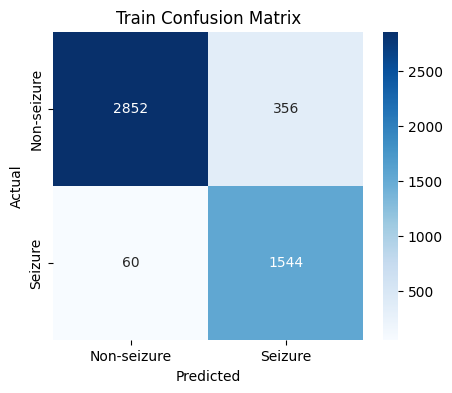

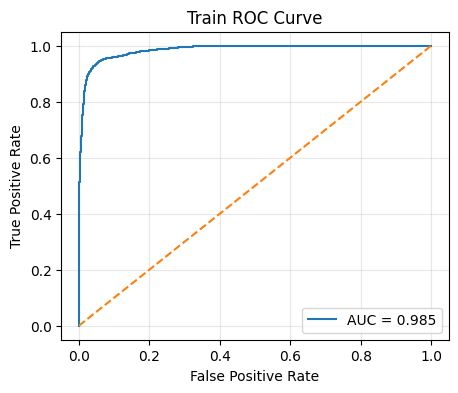

In [52]:
# ==========================================
# LOAD BEST MODEL
# ==========================================

model.load_state_dict(best_state)

# ==========================================
# EVALUATE TRAIN SET
# ==========================================

_, _, _, _, _, tr_probs, tr_targets = evaluate(
    model,
    train_seq_new,
    train_lbl_new,
    criterion,
    threshold=best_thr_saved
)

tr_preds = (np.array(tr_probs) >= best_thr_saved).astype(int)

# ==========================================
# REPORT
# ==========================================

print("\n📊 TRAIN REPORT")
print(classification_report(tr_targets, tr_preds))

# ==========================================
# CONFUSION MATRIX
# ==========================================

plot_confusion_matrix(
    tr_targets,
    tr_preds,
    "Train Confusion Matrix"
)

# ==========================================
# ROC CURVE
# ==========================================

plot_roc_curve(
    tr_targets,
    tr_probs,
    "Train ROC Curve"
)

### Run — Plot Training Curves
Displays the loss and F1 training history.

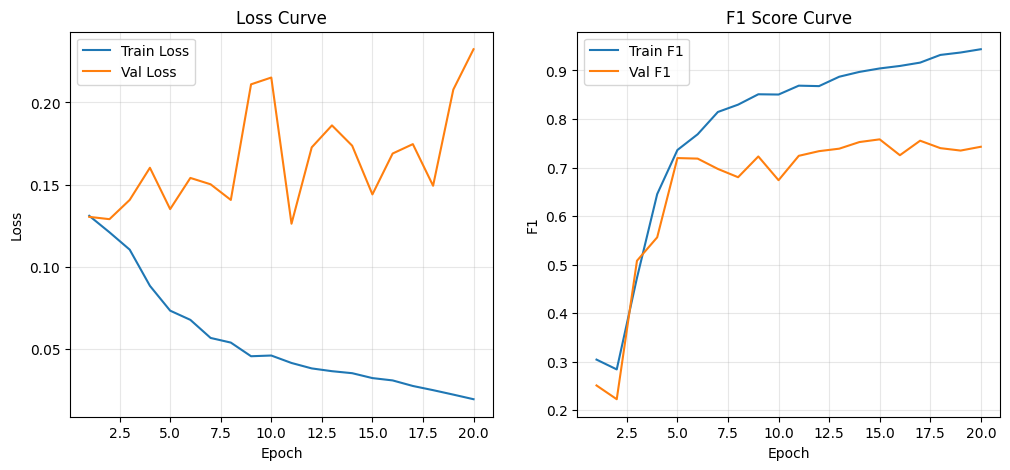

In [53]:
plot_training_curves(history)

### Run — Test Set Evaluation
Final evaluation on the held-out test set. Prints classification report, confusion matrix, and ROC curve.


📊 TEST REPORT
              precision    recall  f1-score   support

           0       0.89      0.86      0.88      1110
           1       0.74      0.78      0.76       555

    accuracy                           0.84      1665
   macro avg       0.81      0.82      0.82      1665
weighted avg       0.84      0.84      0.84      1665



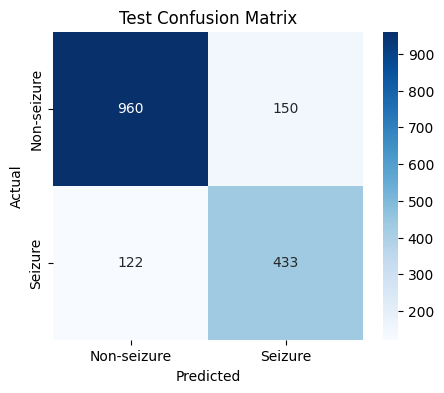

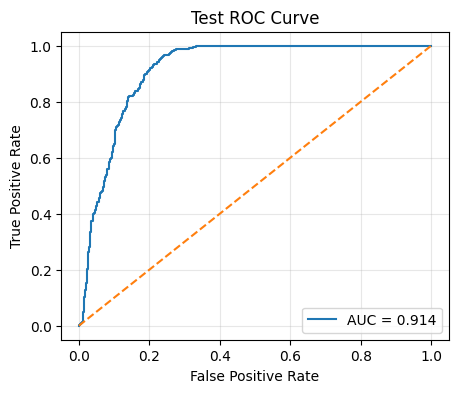

In [54]:
# ==========================================
# LOAD BEST MODEL
# ==========================================

model.load_state_dict(best_state)

# ==========================================
# EVALUATE TEST SET
# ==========================================

_, _, _, _, _, te_probs, te_targets = evaluate(
    model,
    test_seq,
    test_lbl,
    criterion,
    threshold=best_thr_saved
)

# ==========================================
# APPLY BEST THRESHOLD
# ==========================================

te_preds = (np.array(te_probs) >= best_thr_saved).astype(int)

# ==========================================
# TEST REPORT
# ==========================================

print("\n📊 TEST REPORT")
print(classification_report(te_targets, te_preds))

# ==========================================
# CONFUSION MATRIX
# ==========================================

plot_confusion_matrix(
    te_targets,
    te_preds,
    "Test Confusion Matrix"
)

# ==========================================
# ROC CURVE
# ==========================================

plot_roc_curve(
    te_targets,
    te_probs,
    "Test ROC Curve"
)

## Phase 10 — 5-Fold Cross-Validation

Runs a full **5-fold GroupKFold** cross-validation loop where folds are split by patient ID, ensuring no patient's data leaks between train and test sets.

For each fold:
- A fresh `GNN_LSTM_Model` is instantiated and trained for up to 25 epochs with early stopping (patience=6).
- Per-epoch threshold optimisation (`precision > 0.5`, `recall > 0.3`) is applied on the test split.
- The best model state is restored and final metrics (Accuracy, Precision, Recall, F1, ROC-AUC) are recorded.

After all folds, mean ± std for every metric is printed as the final cross-validation summary.

In [ ]:


from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import numpy as np
import torch
import copy



N_SPLITS = 5

gkf = GroupKFold(n_splits=N_SPLITS)

X = filtered_sequences
Y = np.array(filtered_labels)
GROUPS = np.array(filtered_patient_ids)



fold_results = []


for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, Y, GROUPS), 1
):

    print("\n" + "=" * 60)
    print(f"FOLD {fold}/{N_SPLITS}")
    print("=" * 60)



    test_seq  = [X[i] for i in test_idx]
    train_seq = [X[i] for i in train_idx]
    train_lbl = Y[train_idx]

    test_seq  = [X[i] for i in test_idx]
    test_lbl = Y[test_idx]

    train_groups = GROUPS[train_idx]
    test_groups  = GROUPS[test_idx]

    print("\nTrain patients:")
    print(sorted(set(train_groups)))

    print("\nTest patients:")
    print(sorted(set(test_groups)))

    print("\nTrain distribution:")
    print(np.bincount(train_lbl))

    print("\nTest distribution:")
    print(np.bincount(test_lbl))

   

    model = GNN_LSTM_Model().to(DEVICE)

    criterion = FocalLoss(
        alpha=0.75,
        gamma=2.0
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=1e-6
    )


    EPOCHS = 25

    best_f1 = 0.0
    best_thr = 0.5
    best_state = None

    patience = 6
    no_improve = 0

    for epoch in range(1, EPOCHS + 1):

        

        tr_loss, tr_acc, tr_prec, tr_rec, tr_f1 = train_epoch(
            model,
            train_seq,
            train_lbl,
            optimizer,
            criterion
        )


        te_loss, _, _, _, _, te_probs, te_targets = evaluate(
            model,
            test_seq,
            test_lbl,
            criterion,
            threshold=0.5
        )

        

        best_epoch_f1 = 0.0
        best_epoch_thr = 0.5

        for thr in np.arange(0.10, 0.95, 0.01):

            preds = (np.array(te_probs) >= thr).astype(int)

            prec = precision_score(
                te_targets,
                preds,
                zero_division=0
            )

            rec = recall_score(
                te_targets,
                preds,
                zero_division=0
            )

            f1 = f1_score(
                te_targets,
                preds,
                zero_division=0
            )

            if prec > 0.5 and rec > 0.3 and f1 > best_epoch_f1:
                best_epoch_f1 = f1
                best_epoch_thr = thr

        

        if best_epoch_f1 > best_f1:

            best_f1 = best_epoch_f1
            best_thr = best_epoch_thr

            best_state = copy.deepcopy(
                model.state_dict()
            )

            no_improve = 0

        else:
            no_improve += 1

        scheduler.step()

        print(
            f"\nEpoch {epoch}/{EPOCHS}"
            f" | Train F1: {tr_f1:.4f}"
            f" | Test F1: {best_epoch_f1:.4f}"
            f" | Thr: {best_epoch_thr:.2f}"
        )

       

        if no_improve >= patience:

            print(
                f"\nEarly stopping at epoch {epoch}"
            )

            break


    model.load_state_dict(best_state)

    

    _, _, _, _, _, probs, targets = evaluate(
        model,
        test_seq,
        test_lbl,
        criterion,
        threshold=best_thr
    )

    preds = (np.array(probs) >= best_thr).astype(int)

    acc = accuracy_score(targets, preds)

    prec = precision_score(
        targets,
        preds,
        zero_division=0
    )

    rec = recall_score(
        targets,
        preds,
        zero_division=0
    )

    f1 = f1_score(
        targets,
        preds,
        zero_division=0
    )

    auc = roc_auc_score(
        targets,
        probs
    )

   
    fold_results.append({
        "fold": fold,
        "acc": acc,
        "prec": prec,
        "rec": rec,
        "f1": f1,
        "auc": auc
    })

    print("\nFINAL FOLD RESULTS")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")



print("\n" + "=" * 60)
print("FINAL CROSS-VALIDATION RESULTS")
print("=" * 60)

accs  = [x["acc"]  for x in fold_results]
precs = [x["prec"] for x in fold_results]
recs  = [x["rec"]  for x in fold_results]
f1s   = [x["f1"]   for x in fold_results]
aucs  = [x["auc"]  for x in fold_results]

print(f"\nAccuracy : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
print(f"Recall   : {np.mean(recs):.4f} ± {np.std(recs):.4f}")
print(f"F1 Score : {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
print(f"ROC AUC  : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")